In [3]:
!pip install nltk
import nltk 
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/vydhyamvishnusai/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
!pip install numpy 
!pip install pandas
!pip install scikit-learn


In [5]:
import numpy as np 
import pandas as pd 
import sklearn
from sklearn.datasets import fetch_20newsgroups 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
import re 
import nltk
from nltk.stem import WordNetLemmatizer 
from nltk.tokenize import word_tokenize 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.model_selection import train_test_split


In [6]:
p_spam = 3000 / 10000
p_ham = 7000/ 10000 
word_probs_spam = {'get': 900/ 10000, 'free': 1200/ 10000, 'money': 1100/10000, 'now': 800/ 10000}
word_probs_ham = {'get': 150/ 10000, 'free': 70/ 10000, 'money': 60/10000, 'now': 100/ 10000} 
#calculate probability propotional to spam and ham 
p_sms_givem_spam = p_spam 
for word in ['get', 'free', 'money', 'now']:
    p_sms_givem_spam *= word_probs_spam[word]
p_sms_given_ham = p_ham 
for word in ['get', 'free', 'money', 'now']:
    p_sms_given_ham *= word_probs_ham[word]
print(f"Probability of SMS being spam:{ p_sms_givem_spam:.10f}")
print(f"Probability of SMS being ham:{ p_sms_given_ham:.10f}") 
print("Prediction:", "spam" if p_sms_givem_spam > p_sms_given_ham else "Ham")


Probability of SMS being spam:0.0000285120
Probability of SMS being ham:0.0000000044
Prediction: spam


# sample email dataset

In [7]:
data = {
    'text': [
        "Free money now!!!",
        "Hi Bob, how about a game tomorrow?",
        "Earn cash fast, click here!",
        "Are we meeting today for dinner?",
        "Limited offer, get free coupons!",
        "Don't forget the meeting at 10 am"
    ],
    'label': ['spam', 'ham', 'spam', 'ham', 'spam', 'ham']
} 
df = pd.DataFrame(data)
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    tokens = word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(lemmas)
df['processed'] = df['text'].apply(preprocess)
print(df[['text', 'processed', 'label']])


                                 text                             processed  \
0                   Free money now!!!                  free money now ! ! !   
1  Hi Bob, how about a game tomorrow?  hi bob , how about a game tomorrow ?   
2         Earn cash fast, click here!         earn cash fast , click here !   
3    Are we meeting today for dinner?     are we meeting today for dinner ?   
4    Limited offer, get free coupons!     limited offer , get free coupon !   
5   Don't forget the meeting at 10 am    do n't forget the meeting at 10 am   

  label  
0  spam  
1   ham  
2  spam  
3   ham  
4  spam  
5   ham  


# TF-IDF

In [8]:
vectorizer = TfidfVectorizer(ngram_range= (1,2))
x = vectorizer.fit_transform(df['processed'])
features = vectorizer.get_feature_names_out() 
print(f"Number of features:{len(features)}")
print("Sample Features", features[:10])
print("\nTF-IDF Vectoirs (first email):") 
print(x.toarray()[0])

Number of features:56
Sample Features ['10' '10 am' 'about' 'about game' 'am' 'are' 'are we' 'at' 'at 10' 'bob']

TF-IDF Vectoirs (first email):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.37935895 0.         0.46262479
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.46262479 0.46262479 0.46262479 0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]


In [9]:
!pip install matplotlib


Classification Report:
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



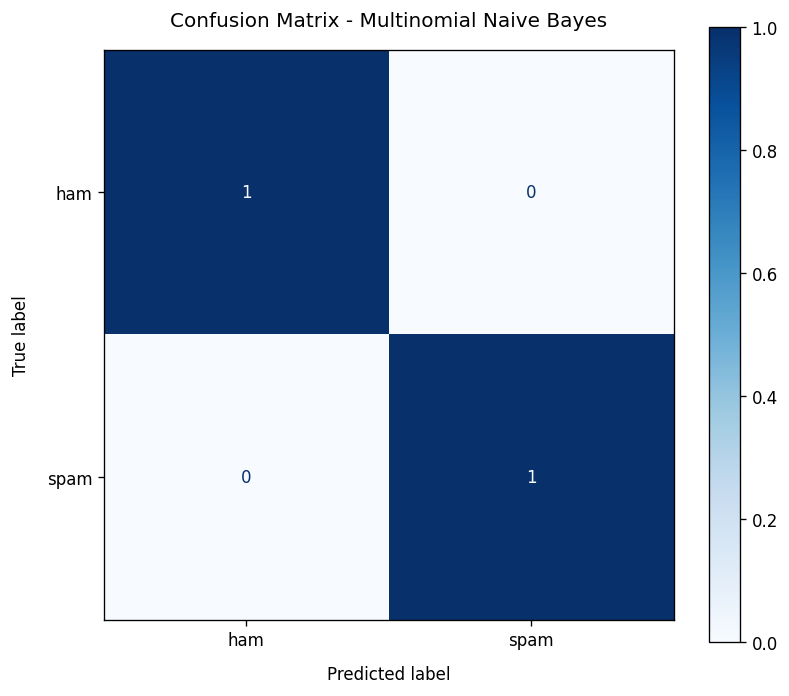

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

x_train, x_test, y_train, y_test = train_test_split(
    x,
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

model = MultinomialNB()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)
display.plot(
    ax=ax,
    cmap='Blues',
    values_format='d',
    colorbar=True
)
ax.set_title("Confusion Matrix - Multinomial Naive Bayes", pad=14)
ax.set_xlabel("Predicted label", labelpad=10)
ax.set_ylabel("True label", labelpad=10)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

In [11]:
feature_log_probs = model.feature_log_prob_
print(feature_log_probs) 

[[-4.13722317 -4.13722317 -3.87369701 -3.87369701 -4.13722317 -3.87017479
  -3.87017479 -4.13722317 -4.13722317 -3.87369701 -3.87369701 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -4.13722317 -3.87017479 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -4.13722317 -4.13722317 -3.87017479
  -3.87017479 -4.13722317 -4.13722317 -4.13722317 -4.13722317 -4.13722317
  -3.87369701 -3.87369701 -4.13722317 -4.13722317 -4.13722317 -3.87369701
  -3.87369701 -3.87369701 -3.87369701 -4.13722317 -4.13722317 -3.91327246
  -4.13722317 -3.87017479 -4.13722317 -4.13722317 -4.13722317 -4.13722317
  -4.13722317 -4.13722317 -4.13722317 -3.87017479 -3.87017479 -3.87369701
  -3.87017479 -3.87017479]
 [-4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398
  -4.12705398 -4.12705398 -4.12705398 -4.12705398 -4.12705398 -3.83937191
  -3.83937191 -3.83937191 -3.83937191 -3.83470506 -4.12705398 -4.12705398
  -4.12705398 -3.83937191 -3.83937191 -3.83937191 -3.83937191 -4.12705398
  -4.127053

In [12]:
#download and load sms spam collection dataset 

# Step 1: Download and unzip
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
!unzip smsspamcollection.zip

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'text'])

--2026-09-18 16:15:00--  https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 64:ff9b::80c3:afc, 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|64:ff9b::80c3:afc|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘smsspamcollection.zip.4’

smsspamcollection.z     [     <=>            ] 198.65K   170KB/s    in 1.2s    

2026-09-18 16:15:02 (170 KB/s) - ‘smsspamcollection.zip.4’ saved [203415]

Archive:  smsspamcollection.zip
replace SMSSpamCollection? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

OSError: [Errno 5] Input/output error

In [13]:
print(df.shape)

(6, 3)


In [14]:
df.groupby('label').size()

label
ham     3
spam    3
dtype: int64

In [ ]:
df.head()

,text,label,processed
0,Free money now!!!,spam,free money now ! ! !
1,"Hi Bob, how about a game tomorrow?",ham,"hi bob , how about a game tomorrow ?"
2,"Earn cash fast, click here!",spam,"earn cash fast , click here !"
3,Are we meeting today for dinner?,ham,are we meeting today for dinner ?
4,"Limited offer, get free coupons!",spam,"limited offer , get free coupon !"


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.metrics import confusion_matrix, classification_report 
x_train_np, x_test_np, y_train_np, y_test_np = train_test_split(df['text'],df['label'], test_size = 0.2, 
                                                                random_state = 42, stratify = df['label'])
count_vec = CountVectorizer(stop_words = 'english', max_features = 2000)
x_train_vec_np = count_vec.fit_transform(x_train_np)
x_test_vec_np = count_vec.transform(x_test_np) 

model_np = MultinomialNB()
model_np.fit(x_train_vec_np, y_train_np)
y_pred_np = model_np.predict(x_test_vec_np) 
print(confusion_matrix(y_test_np, y_pred_np))
print("Accuracy:", (y_test_np == y_pred_np).mean())
print("Classification report:", classification_report(y_test_np, y_pred_np))


[[1 0]
 [0 1]]
Accuracy: 1.0
Classification report:               precision    recall  f1-score   support

         ham       1.00      1.00      1.00         1
        spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:
from nltk.corpus import stopwords 
import string 
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\s+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\d+', '', text) 

    text = text .translate(str.maketrans('', '', string.punctuation)) 
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ''.join(tokens)
df['clean_text'] = df['text'].astype(str).apply(clean_text)
print(df[['text', 'clean_text', 'label']].head())


                                 text                 clean_text label
0                   Free money now!!!                  freemoney  spam
1  Hi Bob, how about a game tomorrow?          hibobgametomorrow   ham
2         Earn cash fast, click here!          earncashfastclick  spam
3    Are we meeting today for dinner?         meetingtodaydinner   ham
4    Limited offer, get free coupons!  limitedoffergetfreecoupon  spam


In [ ]:
x_train_prep, x_test_prep, y_train_prep, y_test_prep = train_test_split(
    df['clean_text'], df['label'], test_size = 0.2, random_state = 42, stratify = df['label']
) 
tfidf_vec = TfidfVectorizer(ngram_range = (1,2), stop_words = 'english', max_features = 2000)
x_train_vec_prep = tfidf_vec.fit_transform(x_train_prep) 
x_test_vec_prep = tfidf_vec.transform(x_test_prep)
model_prep = MultinomialNB()
model_prep.fit(x_train_vec_prep, y_train_prep) 
y_pred_prep = model_prep.predict(x_test_vec_prep)
print("TF-IDF Vectorizer")
print(confusion_matrix(y_test_prep, y_pred_prep))
print("Accuracy", (y_test_prep == y_pred_prep).mean())
print("Classification Report:")
print(classification_report(y_test_prep, y_pred_prep)) 




TF-IDF Vectorizer
[[1 0]
 [1 0]]
Accuracy 0.5
Classification Report:
              precision    recall  f1-score   support

         ham       0.50      1.00      0.67         1
        spam       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/opt/anaconda3/envs/mlproject/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/mlproject/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/mlproject/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

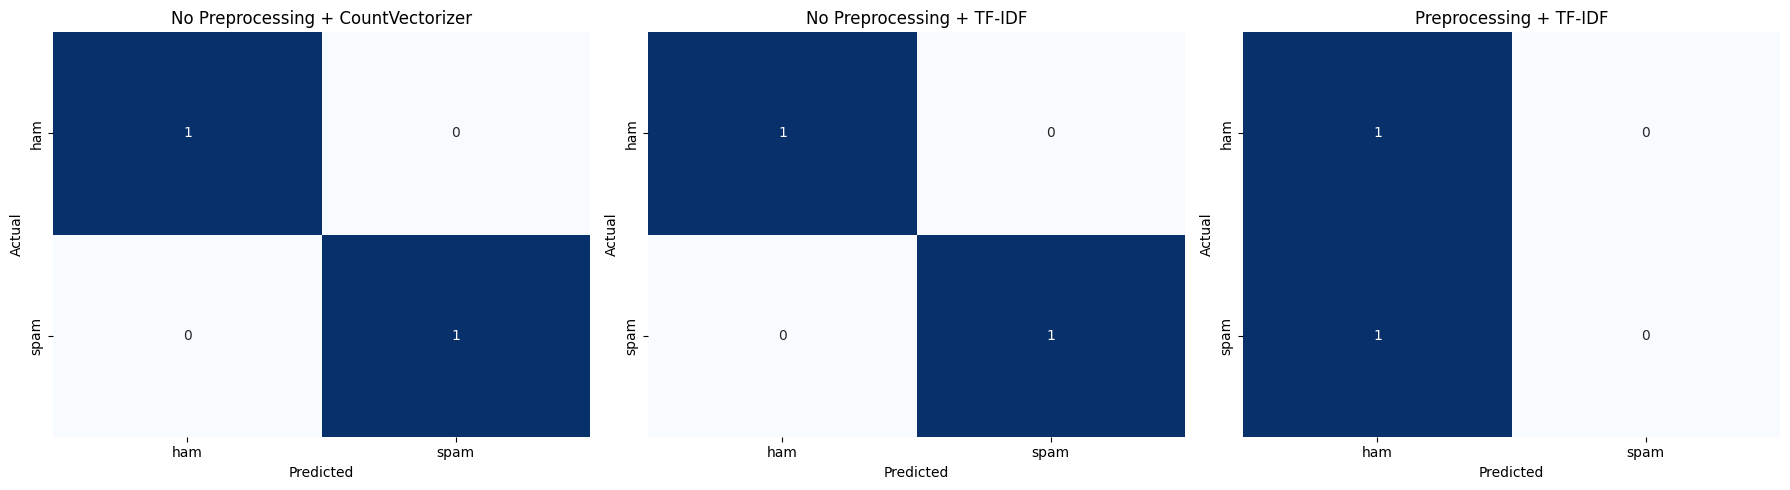

In [ ]:
import seaborn as sns
# Common splits for fair ablation
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['label'], test_size=0.25, random_state=42, stratify=df['label']
)

X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(
    df['clean_text'], df['label'], test_size=0.25, random_state=42, stratify=df['label']
)

# 1. No Preproc + CountVectorizer
count_vec = CountVectorizer(stop_words='english', max_features=2000)
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv = count_vec.transform(X_test)

model_cv = MultinomialNB().fit(X_train_cv, y_train)
y_pred_cv = model_cv.predict(X_test_cv)
cm_cv = confusion_matrix(y_test, y_pred_cv)




tfidf_vec_np = TfidfVectorizer(ngram_range=(1,2), stop_words='english', max_features=2000)
X_train_tfidf_np = tfidf_vec_np.fit_transform(X_train)
X_test_tfidf_np = tfidf_vec_np.transform(X_test)
model_tfidf_np = MultinomialNB().fit(X_train_tfidf_np, y_train)
y_pred_tfidf_np = model_tfidf_np.predict(X_test_tfidf_np)
cm_tfidf_np = confusion_matrix(y_test, y_pred_tfidf_np)

# 3. Preproc + TF-IDF
tfidf_vec_prep = TfidfVectorizer(ngram_range=(1,2), stop_words='english', max_features=2000)
X_train_tfidf_prep = tfidf_vec_prep.fit_transform(X_train_prep)
X_test_tfidf_prep = tfidf_vec_prep.transform(X_test_prep)
model_tfidf_prep = MultinomialNB().fit(X_train_tfidf_prep, y_train_prep)
y_pred_tfidf_prep = model_tfidf_prep.predict(X_test_tfidf_prep)
cm_tfidf_prep = confusion_matrix(y_test_prep, y_pred_tfidf_prep)

fig, axes = plt.subplots(1,3, figsize = (18,5))
titles = [
    'No Preprocessing + CountVectorizer',
    'No Preprocessing + TF-IDF',
    'Preprocessing + TF-IDF'
] 
cms = [cm_cv, cm_tfidf_np, cm_tfidf_prep] 
for i , ax in enumerate(axes):
    sns.heatmap(cms[i], annot = True, cmap = 'Blues', fmt = 'd', cbar = False,xticklabels = ['ham', 'spam'], yticklabels = ['ham', 'spam'], ax = ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(titles[i])
plt.tight_layout()
plt.show()


label
10    999
15    997
8     996
9     994
11    991
13    990
7     990
5     988
14    987
2     985
12    984
3     982
6     975
1     973
4     963
17    940
16    910
0     799
18    775
19    628
Name: count, dtype: int64


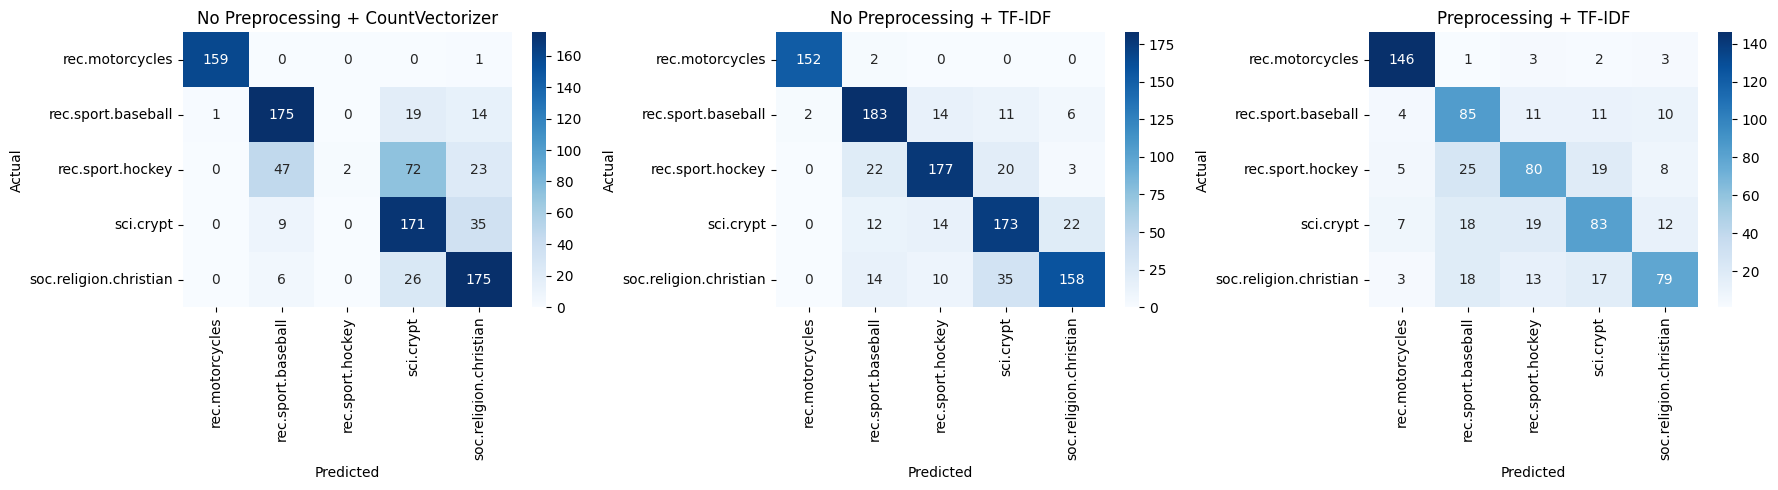

In [ ]:
from sklearn.datasets import fetch_20newsgroups 
import pandas as pd 
data = fetch_20newsgroups(subset = 'all', remove = ())
df_news = pd.DataFrame({'text': data.data, 'label':data.target}) 
df_news['label_name'] = df_news['label'].map((lambda x:data.target_names[x])) 
print(df_news['label'].value_counts()) 
lemmatizer = WordNetLemmatizer() 
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\W\S]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = nltk.word_tokenize(text) 
    tokens = [lemmatizer.lemmatize(token, pos = 'v') for token in tokens] 
    return ''.join(tokens)
df_news['clean_text'] = df_news['text'].apply(preprocess)
x_train, x_test, y_train , y_test = train_test_split(df_news['text'], df_news['label_name'], test_size = 0.25, random_state = 42, stratify = df_news['label_name'])
x_train_prep, x_test_prep, y_train_prep, y_test_prep = train_test_split(df_news['clean_text'], df_news['label_name'], test_size = 0.25, random_state = 42, stratify = df_news['label_name'])

#no preprocess + countvectorizer 
count_vec = CountVectorizer(stop_words = 'english', max_features = 2000)
x_train_cv = count_vec.fit_transform(x_train)
x_test_cv = count_vec.transform(x_test)
model_cv = MultinomialNB().fit(x_train_cv, y_train)
y_pred_cv = model_cv.predict(x_test_cv)
cm_cv = confusion_matrix(y_test, y_pred_cv)

#no preprocess + with Tfidf 
tfidf_vec_np = TfidfVectorizer(ngram_range = (1,2), stop_words = 'english', max_features = 2000) 
x_train_tfidf_np = tfidf_vec_np.fit_transform(x_train)
x_test_tfidf_np = tfidf_vec_np.transform(x_test)
model_tfidf_np = MultinomialNB().fit(x_train_tfidf_np,y_train) 
y_pred_tfidf_np = model_tfidf_np.predict(x_test_tfidf_np)
cm_tfidf_np = confusion_matrix(y_test, y_pred_tfidf_np)

#preproc + TDIDF 
tfidf_vec_prep = TfidfVectorizer(ngram_range = (1,2), stop_words = 'english', max_features = 2000) 
x_train_tfidf_prep = tfidf_vec_prep.fit_transform(x_train_prep)
x_test_tfidf_prep = tfidf_vec_prep.transform(x_test_prep)
model_tfidf_prep = MultinomialNB().fit(x_train_tfidf_prep,y_train_prep) 
y_pred_tfidf_prep = model_tfidf_prep.predict(x_test_tfidf_prep)
cm_tfidf_prep = confusion_matrix(y_test_prep, y_pred_tfidf_prep) 
labels_to_show = df_news['label_name'].value_counts().index[:5].tolist() 
def plot_conf_matrix(matrix, y_true, y_pred, title):
    # Pick top N classes for simpler visualization
    from sklearn.utils.multiclass import unique_labels
    labs = unique_labels(y_true, y_pred)
    labs = [l for l in labs if l in labels_to_show]
    idx = [i for i, l in enumerate(labs)]
    matrix = matrix[idx, :][:, idx]
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labs, yticklabels=labs)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plot_conf_matrix(cm_cv, y_test, y_pred_cv, 'No Preprocessing + CountVectorizer')

plt.subplot(1, 3, 2)
plot_conf_matrix(cm_tfidf_np, y_test, y_pred_tfidf_np, 'No Preprocessing + TF-IDF')

plt.subplot(1, 3, 3)
plot_conf_matrix(cm_tfidf_prep, y_test_prep, y_pred_tfidf_prep, 'Preprocessing + TF-IDF')

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

    negative       0.25      0.33      0.29         3
    positive       0.00      0.00      0.00         3

    accuracy                           0.17         6
   macro avg       0.12      0.17      0.14         6
weighted avg       0.12      0.17      0.14         6



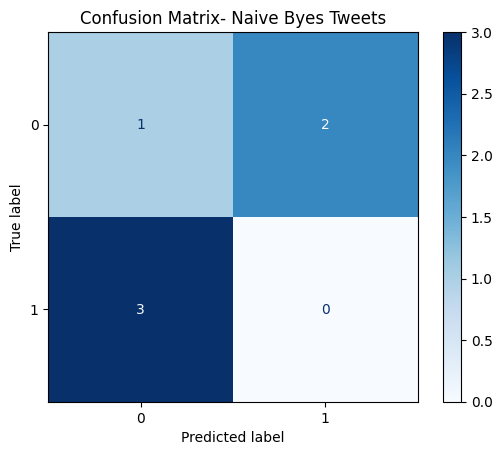

In [18]:
tweets = [
    "Love the new AI update! #excited #AI",
    "Worst game ever. totally boring and laggy :(",
    "Check out this cool link http://example.com #tech",
    "Can't wait for the weekend! @friend",
    "This update is not good at all, very buggy!",

    "Amazing new features in the latest update! 🔥 #awesome #AI",
    "I hate this app update. Everything feels broken 😡",
    "Just discovered an interesting article https://example.com #technology",
    "Happy birthday @john! Hope you have an amazing day 🎉",
    "The new phone looks absolutely fantastic! #Apple #innovation",
    
    "What a terrible experience. Never using this service again!",
    "Watching an amazing movie tonight 🎬 #weekend #movies",
    "Follow @techguru for more updates! #TechNews",
    "This website is really slow today 😩 http://test.com",
    "I am so excited about the new AI model! 🚀 #MachineLearning",
    
    "The game was okay, but the graphics could be better.",
    "Fantastic performance by the team today! ❤️ #sports",
    "Don't miss this useful tutorial https://example.com/tutorial #coding",
    "Why is this app crashing every five minutes? 😤",
    "Good morning everyone! Have a productive day ☀️ #Monday",
    
    "This is the best laptop I've ever used! 💻 #MacBook",
    "Very disappointed with the customer service.",
    "@alex you need to see this! 😂 https://example.com",
    "Learning Python is actually fun! 🐍 #Programming #Python",
    "The latest update fixed so many bugs. Great job! 👏",
    
    "Such a boring movie. I almost fell asleep 😴",
    "AI is changing the way we build software! 🤖 #AI #Future",
    "Check this amazing project out @developer #opensource",
    "Not impressed with the new design at all.",
    "Finally got my certificate! 🎓 So happy! #Achievement"
]
labels = [
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'neutral', 'positive', 'negative'
]
x_train, x_test, y_train, y_test = train_test_split(tweets, labels, test_size = 0.2, random_state = 41)
def tweet_preprocess(text):
    token = word_tokenize(text.lower())
    lemmatizer = WordNetLemmatizer()
    lemmas = [lemmatizer.lemmatize(t) for t in token]
    return " ".join(lemmas)
x_train_prep = [tweet_preprocess(tweet) for tweet in x_train]
x_test_prep = [tweet_preprocess(tweet) for tweet in x_test] 

vectorizer = TfidfVectorizer(ngram_range = (1,2))
x_train_vec = vectorizer.fit_transform(x_train_prep)
x_test_vec = vectorizer.transform(x_test_prep)
model_tweet = MultinomialNB()
model_tweet.fit(x_train_vec,y_train)
y_pred_tweet = model_tweet.predict(x_test_vec)
print(classification_report(y_test, y_pred_tweet))
cm = confusion_matrix(y_test, y_pred_tweet)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = 'Blues')
plt.title("Confusion Matrix- Naive Byes Tweets")
plt.show()